In [5]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tqdm import tqdm
from scipy.linalg import sqrtm
import kagglehub

In [6]:
path = kagglehub.dataset_download("splcher/animefacedataset")

print("Ruta descargada:", path)
print("Contenido del directorio raíz:", os.listdir(path))

100%|██████████| 395M/395M [00:02<00:00, 154MB/s]

Extracting files...


Ruta descargada: /root/.cache/kagglehub/datasets/splcher/animefacedataset/versions/3
Contenido del directorio raíz: ['images']


Total de imágenes encontradas: 63565
Ejemplo de imagen: /root/.cache/kagglehub/datasets/splcher/animefacedataset/versions/3/images/21846_2008.jpg
Tamaño original: (84, 84)
Modo de color: RGB


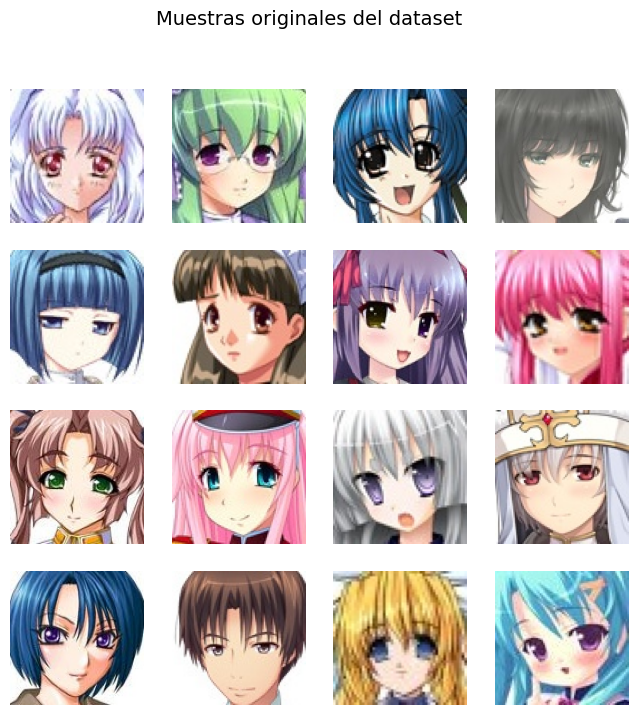

In [9]:
# Ruta del dataset
dataset_path = "/root/.cache/kagglehub/datasets/splcher/animefacedataset/versions/3/images"

# Comprobar cantidad de imágenes
image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png'))]
print(f"Total de imágenes encontradas: {len(image_files)}")

# Inspeccionar una imagen aleatoria
sample_path = np.random.choice(image_files)
img = Image.open(sample_path)
print("Ejemplo de imagen:", sample_path)
print("Tamaño original:", img.size)
print("Modo de color:", img.mode)  # RGB o L

# Mostrar algunas imágenes aleatorias (sin preprocesar)
plt.figure(figsize=(8,8))
for i in range(16):
    path = np.random.choice(image_files)
    img = Image.open(path)
    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Muestras originales del dataset", fontsize=14)
plt.show()


Procesando imágenes: 100%|██████████| 63565/63565 [00:26<00:00, 2354.29it/s]



Total de imágenes procesadas correctamente: 63565
Forma final del dataset: (63565, 64, 64, 1)


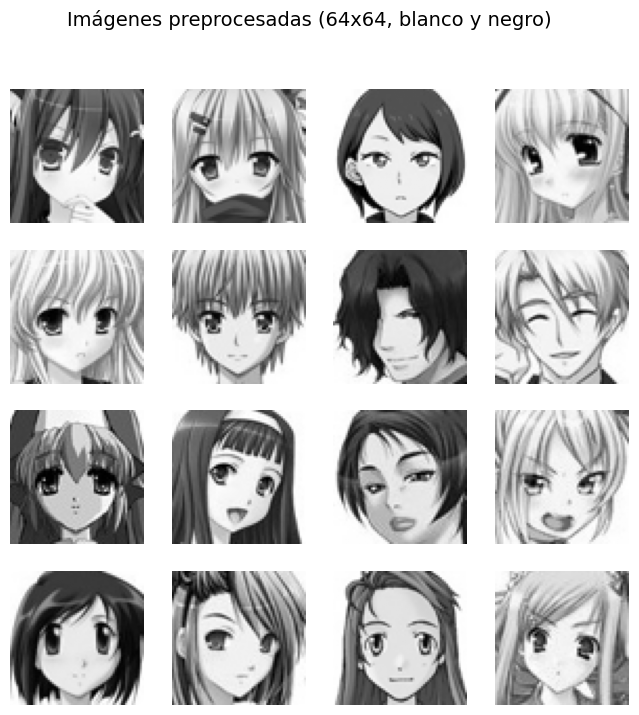

In [10]:
IMG_SIZE = 64
BATCH_SIZE = 128

def preprocess_images(file_list):
    data = []
    for file in tqdm(file_list, desc="Procesando imágenes"):
        try:
            img = Image.open(file).convert("L")  # Convertir a escala de grises
            img = img.resize((IMG_SIZE, IMG_SIZE))  # Redimensionar
            img = np.array(img, dtype=np.float32)
            img = (img - 127.5) / 127.5  # Normalizar a [-1, 1]
            data.append(img)
        except Exception as e:
            print(f"Error procesando {file}: {e}")
    data = np.expand_dims(np.array(data), axis=-1)  # (n, 64, 64, 1)
    return data

# Preprocesar todas las imágenes
data = preprocess_images(image_files)

print(f"\nTotal de imágenes procesadas correctamente: {data.shape[0]}")
print(f"Forma final del dataset: {data.shape}")

# Crear dataset de TensorFlow
BUFFER_SIZE = data.shape[0]
dataset = tf.data.Dataset.from_tensor_slices(data).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Mostrar algunas imágenes preprocesadas
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(data[i, :, :, 0] * 0.5 + 0.5, cmap="gray")
    plt.axis("off")
plt.suptitle("Imágenes preprocesadas (64x64, blanco y negro)", fontsize=14)
plt.show()

In [11]:
# Generador
def build_generator():
    model = tf.keras.Sequential(name="Generator")

    # Capa densa inicial: expande el vector de entrada (ruido) a un tensor 8x8x512
    model.add(layers.Dense(8*8*512, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())  # Normaliza activaciones para estabilizar el entrenamiento
    model.add(layers.LeakyReLU())  # Activa las neuronas evitando el problema del "dying ReLU"
    model.add(layers.Reshape((8, 8, 512)))  # Reorganiza el vector en un mapa de características 8x8

    # Primera capa de deconvolución: 8x8 → 16x16
    model.add(layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Segunda capa de deconvolución: 16x16 → 32x32
    model.add(layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Tercera capa de deconvolución: 32x32 → 64x64
    model.add(layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Capa de salida: genera una imagen 64x64x1 con valores en [-1, 1]
    model.add(layers.Conv2DTranspose(1, 4, strides=1, padding="same", use_bias=False, activation="tanh"))
    return model




In [12]:
# Discriminador:
def build_discriminator():
    model = models.Sequential(name="Discriminator")

    # Capa de entrada: recibe una imagen 64x64x1
    model.add(layers.Conv2D(64,  kernel_size=4, strides=2, padding="same", input_shape=[64, 64, 1]))
    model.add(layers.LeakyReLU())  # Activación robusta ante valores negativos
    model.add(layers.Dropout(0.3))  # Evita sobreajuste reduciendo la dependencia entre neuronas

    # Segunda capa convolucional: extrae características de mayor nivel
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Aplanado y salida final (sin activación sigmoide, ya que se aplica posteriormente en la pérdida)
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [13]:
# Crear modelos
generator = build_generator()
discriminator = build_discriminator()

# Mostrar resúmenes
generator.summary()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32768)          │     3,276,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 1)      │         1,024 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,163,200 (23.51 MB)

 Trainable params: 6,096,768 (23.26 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,057 (644.75 KB)

 Trainable params: 165,057 (644.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Binary cross-entropy (BCE) con logits
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Pérdida del discriminador:
#   - Reales -> etiqueta 1
#   - Falsas -> etiqueta 0
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

# Pérdida del generador:
#   - Quiere que el discriminador crea que sus imágenes falsas son reales (etiqueta 1)
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Optimizadores (uno para cada red)
generator_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)


print("Funciones de pérdida y optimizadores configurados correctamente.")


Funciones de pérdida y optimizadores configurados correctamente.


In [2]:
# Bucle de entrenamiento GAN

import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Crear carpetas para guardar imágenes y modelos
os.makedirs("samples", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

epochs = 200
start_epoch = 0
noise_dim = 100
num_examples_to_generate = 16

# Semilla fija para comparar la evolución visual del generador
fixed_seed = tf.random.normal([num_examples_to_generate, noise_dim])

# Cargar modelos guardados si se quiere continuar un entrenamiento anterior
# generator = tf.keras.models.load_model("checkpoints/generator_epoch0050.h5", compile=False)
# discriminator = tf.keras.models.load_model("checkpoints/discriminator_epoch0050.h5", compile=False)

@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, noise_dim])  # Ruido de entrada para el generador

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)  # Generar imágenes falsas

        real_output = discriminator(images, training=True)  # Evaluar imágenes reales
        fake_output = discriminator(generated_images, training=True)  # Evaluar imágenes falsas

        gen_loss = generator_loss(fake_output)  # Pérdida del generador
        disc_loss = discriminator_loss(real_output, fake_output)  # Pérdida del discriminador

    # Calcular gradientes y actualizar parámetros de ambas redes
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# Generar y guardar imágenes de ejemplo durante el entrenamiento
def generate_and_save_images(model, epoch, test_input):
    preds = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))
    for i in range(preds.shape[0]):
        plt.subplot(4, 4, i+1)
        img = preds[i, :, :, 0] * 0.5 + 0.5  # Reescalar a [0, 1]
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"samples/epoch_{epoch:04d}.png")
    plt.close()

# Bucle principal de entrenamiento
def train(dataset, start_epoch, epochs):
    for epoch in range(start_epoch + 1, start_epoch + epochs + 1):
        gen_epoch_loss = 0.0
        disc_epoch_loss = 0.0
        steps = 0

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            gen_epoch_loss += gen_loss
            disc_epoch_loss += disc_loss
            steps += 1

        # Promediar pérdidas por época
        gen_epoch_loss /= tf.cast(steps, tf.float32)
        disc_epoch_loss /= tf.cast(steps, tf.float32)

        generate_and_save_images(generator, epoch, fixed_seed)  # Guardar resultados visuales

        # Guardar modelos cada 10 épocas
        if epoch % 10 == 0:
            generator.save(f"checkpoints/generator_epoch{epoch:04d}.h5")
            discriminator.save(f"checkpoints/discriminator_epoch{epoch:04d}.h5")

        print(f"Epoch {epoch}/{epochs + start_epoch} - Gen loss: {gen_epoch_loss:.4f} - Disc loss: {disc_epoch_loss:.4f}")

# Ejecutar entrenamiento completo
train(dataset, start_epoch, epochs)

# Generar muestra final
generate_and_save_images(generator, epochs, fixed_seed)
print("Entrenamiento finalizado. Revisa la carpeta 'samples' para las imágenes y 'checkpoints' para los pesos.")


NameError: name 'dataset' is not defined

In [15]:
# Cargar modelo guardado
generator = load_model("generator_epoch0200.h5")

N_SAMPLES = 200
noise_dim = 100

# Seleccionar imágenes reales
real_imgs = data[:N_SAMPLES]
real_imgs = tf.convert_to_tensor(real_imgs, dtype=tf.float32)

# Generar imágenes falsas con el generador
noise = tf.random.normal([N_SAMPLES, noise_dim])
fake_imgs = generator(noise, training=False)

print(f"Generadas {N_SAMPLES} imágenes falsas y seleccionadas {N_SAMPLES} reales.")

Generadas 200 imágenes falsas y seleccionadas 200 reales.


In [16]:
def preprocess_for_inception(images):
    # Convertir de (N, 64, 64, 1) → (N, 299, 299, 3)
    images = tf.image.resize(images, (299, 299))
    images = tf.image.grayscale_to_rgb(images)
    # Convertir de [-1, 1] a [0, 255]
    images = (images + 1.0) * 127.5
    # Aplicar preprocesamiento estándar de InceptionV3
    images = preprocess_input(images)
    return images

real_imgs_prep = preprocess_for_inception(real_imgs)
fake_imgs_prep = preprocess_for_inception(fake_imgs)

print("Imágenes preparadas para extracción de características con InceptionV3.")

Imágenes preparadas para extracción de características con InceptionV3.


In [17]:
# Cargar modelo InceptionV3 sin la capa superior para extraer características
inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

# Función para obtener las activaciones intermedias del modelo Inception
def get_activations(model, images, batch_size=32):
    activations = []
    for i in tqdm(range(0, len(images), batch_size), desc="Extrayendo características"):
        batch = images[i:i+batch_size]
        act = model(batch, training=False)  # Pasa las imágenes por la red sin entrenar
        activations.append(act.numpy())
    return np.concatenate(activations, axis=0)  # Une las activaciones en una sola matriz

# Extraer características de las imágenes reales y generadas
act_real = get_activations(inception, real_imgs_prep)
act_fake = get_activations(inception, fake_imgs_prep)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extrayendo características: 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]


In [18]:
# Calcular la media (mu) y la covarianza (sigma) de las activaciones reales y generadas
mu1, sigma1 = act_real.mean(axis=0), np.cov(act_real, rowvar=False)
mu2, sigma2 = act_fake.mean(axis=0), np.cov(act_fake, rowvar=False)

# Calcular el producto de las matrices de covarianza y su raíz cuadrada
covmean = sqrtm(sigma1.dot(sigma2))
if np.iscomplexobj(covmean):  # Eliminar posibles valores complejos por errores numéricos
    covmean = covmean.real

# Cálculo (FID), diferencia estadística entre las distribuciones de imágenes reales y generadas
fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)

print(f"\nFréchet Inception Distance (FID): {fid:.4f}")



Fréchet Inception Distance (FID): 118.2739


In [19]:
# Convertir imágenes generadas (-1 a 1) → (0 a 255)
fake_imgs_uint8 = (fake_imgs * 127.5 + 127.5).numpy().astype(np.uint8)
fake_imgs_flat = fake_imgs_uint8.reshape(N_SAMPLES, -1)  # (200, 4096)

# Crear DataFrame con encabezados
columns = ['ID'] + [str(i) for i in range(fake_imgs_flat.shape[1])]
df = pd.DataFrame(np.column_stack((np.arange(1, N_SAMPLES+1), fake_imgs_flat)), columns=columns)

# Guardar CSV
df.to_csv("generated_images.csv", index=False)

print(f"Archivo 'generated_images.csv' creado con {N_SAMPLES} filas y {fake_imgs_flat.shape[1]} columnas por imagen.")

Archivo 'generated_images.csv' creado con 200 filas y 4096 columnas por imagen.


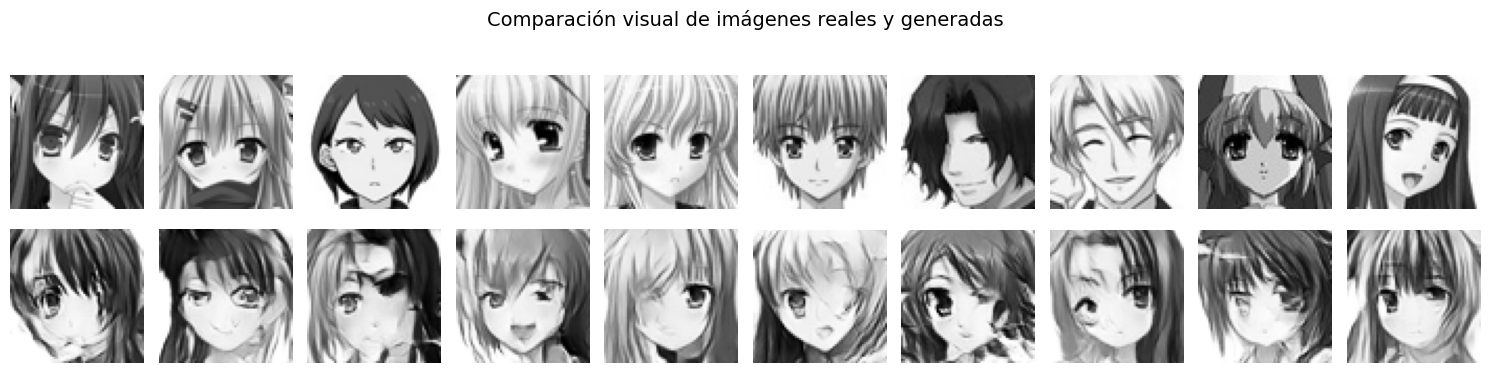

In [20]:
# Comparación imagenes originales vs generadas

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(real_imgs[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(fake_imgs[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Reales", fontsize=12)
axes[1, 0].set_ylabel("Generadas", fontsize=12)
plt.suptitle("Comparación visual de imágenes reales y generadas", fontsize=14)
plt.tight_layout()
plt.show()